# Pipeline OCR chữ Hán cổ (viết dọc, phải → trái) bằng PaddleOCR (detection) + Qwen3-VL-4B-Instruct (recognition)

## 1. Kiểm tra môi trường & GPU

In [1]:
import subprocess, sys, os

print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
print("Python:", sys.version)
print("CWD:", os.getcwd())


Wed Jul 15 08:33:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
import importlib, subprocess, sys
!pip install -q paddlepaddle==3.1.0
!pip install -q paddleocr
!pip install -q ollama

In [4]:
import paddle
import paddleocr

print("Paddle:", paddle.__version__)
print("PaddleOCR:", paddleocr.__version__)

print("CUDA:", paddle.is_compiled_with_cuda())
print("Device:", paddle.device.get_device())

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:715: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle: 3.1.0
PaddleOCR: 3.7.0
CUDA: False
Device: cpu


## 2. Cấu hình đường dẫn & tham số

In [5]:
import sys
import paddle
import paddleocr
import cv2

print("="*50)
print("Python:", sys.version)
print("PaddlePaddle:", paddle.__version__)
print("Compiled with CUDA:", paddle.is_compiled_with_cuda())
print("CUDA device count:", paddle.device.cuda.device_count())

if paddle.device.cuda.device_count() > 0:
    print("Current device:", paddle.device.get_device())

print("PaddleOCR:", paddleocr.__version__)
print("OpenCV:", cv2.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PaddlePaddle: 3.1.0
Compiled with CUDA: False
CUDA device count: 0
PaddleOCR: 3.7.0
OpenCV: 4.10.0


In [6]:
from pathlib import Path

HVB_ID = "HVB_002"
INPUT_MODE = "gdrive"        # "kaggle" hoac "gdrive"

KAGGLE_INPUT_PATH = "/kaggle/input/an-nam-chi-nguyen/scan.pdf"

GDRIVE_LINK = "https://drive.google.com/file/d/1mBTv88Nx7oYxdutZFlBrgAocHs3UAjU4/view?usp=sharing"

PDF_RENDER_DPI = 300

VLM_MODEL_NAME = "qwen3-vl:4b"

WORK_DIR = Path("/kaggle/working")
RAW_INPUT_DIR = WORK_DIR / "raw_input"
PAGES_DIR = WORK_DIR / "pages"
VIS_DETECT_DIR = WORK_DIR / "vis_detect"
VIS_COLUMN_DIR = WORK_DIR / "vis_column"
COLUMN_CROPS_DIR = WORK_DIR / "column_crops"
VIS_RECOG_DIR = WORK_DIR / "vis_recognition"
OUTPUT_DIR = WORK_DIR / "output"

for d in [RAW_INPUT_DIR, PAGES_DIR, VIS_DETECT_DIR, VIS_COLUMN_DIR, COLUMN_CROPS_DIR, VIS_RECOG_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("HVB_ID:", HVB_ID)
print("OUTPUT_DIR:", OUTPUT_DIR)

HVB_ID: HVB_002
OUTPUT_DIR: /kaggle/working/output


## 3. Chuẩn bị input: tải từ Google Drive (nếu cần) và convert PDF scan → ảnh từng trang

In [7]:
import shutil, glob

def prepare_raw_input():
    '''Tra ve list duong dan cac file goc (PDF hoac anh) can xu ly.'''
    if INPUT_MODE == "gdrive":
        import gdown
        print("Tai tu Google Drive ...")
        if "/folders/" in GDRIVE_LINK:
            gdown.download_folder(GDRIVE_LINK, output=str(RAW_INPUT_DIR), quiet=False, use_cookies=False)
        else:
            gdown.download(url=GDRIVE_LINK, output=str(RAW_INPUT_DIR) + "/", quiet=False, fuzzy=True)
        files = sorted(glob.glob(str(RAW_INPUT_DIR / "*")))
    else:
        src = Path(KAGGLE_INPUT_PATH)
        if src.is_dir():
            files = sorted([str(p) for p in src.glob("**/*") if p.suffix.lower() in [".pdf", ".jpg", ".jpeg", ".png", ".tif", ".tiff"]])
        else:
            files = [str(src)]
    if not files:
        raise FileNotFoundError("Khong tim thay file input nao. Kiem tra lai KAGGLE_INPUT_PATH / GDRIVE_LINK.")
    print(f"Tim thay {len(files)} file input:")
    for f in files:
        print(" -", f)
    return files

raw_files = prepare_raw_input()


Tai tu Google Drive ...


Downloading...
From (original): https://drive.google.com/uc?id=1mBTv88Nx7oYxdutZFlBrgAocHs3UAjU4
From (redirected): https://drive.google.com/uc?id=1mBTv88Nx7oYxdutZFlBrgAocHs3UAjU4&confirm=t&uuid=68de1538-5bf5-44e3-b78b-7dee5955bddb
To: /kaggle/working/raw_input/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1.pdf
100%|██████████| 133M/133M [00:00<00:00, 143MB/s]  

Tim thay 1 file input:
 - /kaggle/working/raw_input/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1.pdf


In [8]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 18.8 MB/s eta 0:00:0000:0100:01


In [9]:
from pdf2image import convert_from_path
from PIL import Image
import fitz

def pdf_to_page_images(pdf_path, dpi=300):
    doc = fitz.open(pdf_path)

    pages = []

    zoom = dpi / 72
    mat = fitz.Matrix(zoom, zoom)

    for page in doc:
        pix = page.get_pixmap(matrix=mat)
        img = Image.frombytes(
            "RGB",
            [pix.width, pix.height],
            pix.samples
        )
        pages.append(img)

    doc.close()
    return pages

def build_page_list(files):
    '''Tra ve list tuple (page_id:str, PIL.Image), page_id dang '{stem}_p{idx:04d}'.'''
    page_items = []
    for f in files:
        p = Path(f)
        if p.suffix.lower() == ".pdf":
            pages = pdf_to_page_images(f)
            for i, img in enumerate(pages, start=1):
                page_id = f"{p.stem}_p{i:04d}"
                page_items.append((page_id, img))
        elif p.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]:
            img = Image.open(f).convert("RGB")
            page_items.append((p.stem, img))
    return page_items

page_items = build_page_list(raw_files)
print(f"Tong so trang can OCR: {len(page_items)}")

page_paths = []
for page_id, img in page_items:
    out_path = PAGES_DIR / f"{page_id}.png"
    img.save(out_path)
    page_paths.append((page_id, str(out_path)))

print("Da luu anh trang vao:", PAGES_DIR)


Tong so trang can OCR: 71
Da luu anh trang vao: /kaggle/working/pages


## 4. PaddleOCR — Detection

In [10]:
from paddleocr import TextDetection
import cv2
import numpy as np

text_detector = TextDetection(
    model_name="PP-OCRv5_server_det",
    device="cpu",
)

def detect_boxes(image_path):
    '''
    Tra ve list box, moi box la array 4 diem [[x1,y1],[x2,y2],[x3,y3],[x4,y4]].
    '''
    output = text_detector.predict(image_path, batch_size=1)
    res = next(iter(output))          # output la generator, lay ket qua cua anh dau tien
    boxes = res["dt_polys"]           # numpy array shape (N, 4, 2)
    return boxes

test_page_id, test_page_path = page_paths[0]
test_boxes = detect_boxes(test_page_path)
print(f"Trang {test_page_id}: detect duoc {len(test_boxes)} box chu")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Trang HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001: detect duoc 27 box chu


### 4.1 Visualization bước Detection — kiểm tra box vẽ đúng vị trí chữ chưa

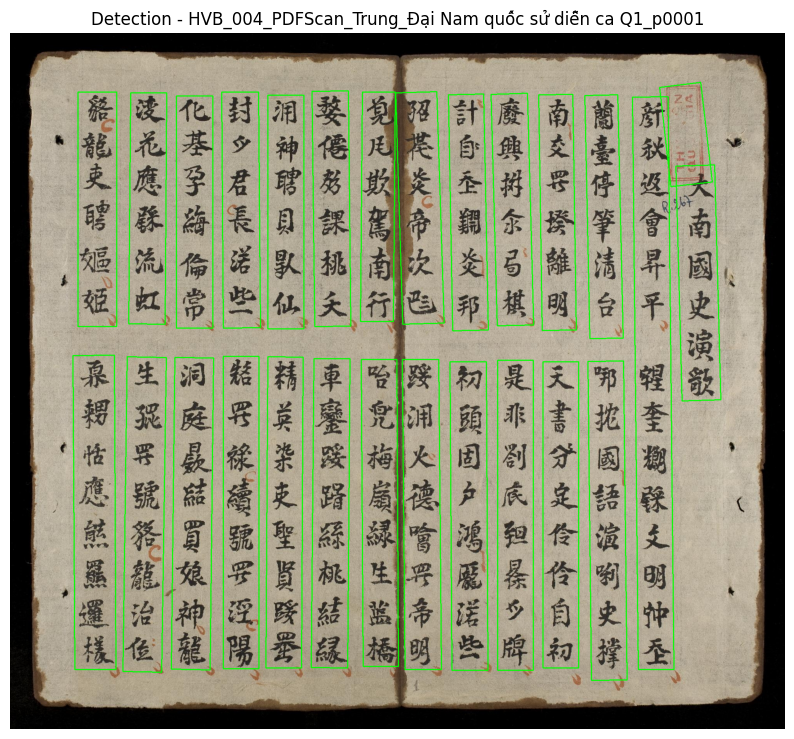

Da luu: /kaggle/working/vis_detect/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001_detect.png


In [11]:

import matplotlib.pyplot as plt

def visualize_boxes(image_path, boxes, save_path, color=(0, 255, 0), thickness=2, title=None):
    img = cv2.imread(image_path)
    for box in boxes:
        pts = np.array(box, dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=thickness)
    cv2.imwrite(str(save_path), img)
    # hien thi luon trong notebook (resize cho vua man hinh)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 14))
    plt.imshow(img_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

vis_path = VIS_DETECT_DIR / f"{test_page_id}_detect.png"
visualize_boxes(test_page_path, test_boxes, vis_path, title=f"Detection - {test_page_id}")
print("Da luu:", vis_path)


## 5. Gom box thành cột dọc (phải → trái), sắp trong cột (trên → dưới)

Cách làm:
1. Tính x-center của từng box.
2. Sắp box theo x-center **giảm dần** (phải trước).
3. Gom cụm theo khoảng cách giữa các x-center liền kề (gap-based 1D clustering): nếu khoảng cách giữa 2 x-center
   kế tiếp (đã sort) lớn hơn ngưỡng (dựa theo bề rộng trung bình của box) thì bắt đầu cột mới.
4. Trong mỗi cột, sắp các box theo **y tăng dần** (trên → dưới).
5. Đánh số cột theo đúng thứ tự đọc: cột 1 = ngoài cùng bên phải.


In [15]:

def box_x_center(box):
    xs = [p[0] for p in box]
    return sum(xs) / len(xs)

def box_y_center(box):
    ys = [p[1] for p in box]
    return sum(ys) / len(ys)

def box_width(box):
    xs = [p[0] for p in box]
    return max(xs) - min(xs)

def box_y_top(box):
    return min(p[1] for p in box)

def group_boxes_into_columns(boxes, gap_ratio=0.6):
    '''
    Gom cac box thanh cac cot doc, tra ve list cot da sap xep phai->trai,
    moi cot la list box da sap xep tren->duoi.

    gap_ratio: he so nhan voi be rong trung binh box de lam nguong tach cot.
               Tang gap_ratio neu bi tach cot qua nhieu (1 cot bi chia lam 2),
               giam gap_ratio neu bi gop nham 2 cot lam 1.
    '''
    if boxes is None or len(boxes) == 0:
        return []

    avg_width = np.median([box_width(b) for b in boxes])
    threshold = max(avg_width * gap_ratio, 5.0)

    # sap theo x-center tang dan de tim gap, sau do se dao nguoc thu tu cot lai (phai->trai)
    boxes_sorted = sorted(boxes, key=box_x_center)
    xs = [box_x_center(b) for b in boxes_sorted]

    columns = []
    current = [boxes_sorted[0]]
    for i in range(1, len(boxes_sorted)):
        if xs[i] - xs[i - 1] > threshold:
            columns.append(current)
            current = []
        current.append(boxes_sorted[i])
    columns.append(current)

    # cot dang o thu tu trai->phai (vi ta sort x tang dan) -> dao nguoc de duoc phai->trai
    columns.reverse()

    # trong tung cot, sap tren->duoi
    columns = [sorted(col, key=box_y_top) for col in columns]
    return columns

test_columns = group_boxes_into_columns(test_boxes)
print(f"Trang {test_page_id}: gom duoc {len(test_columns)} cot, so box moi cot:", [len(c) for c in test_columns])


Trang HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001: gom duoc 14 cot, so box moi cot: [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


### 5.1 Visualization bước gom cột — mỗi cột 1 màu, có đánh số thứ tự đọc

Kiểm tra kỹ bước này: nếu số cột không khớp số cột thật trên trang, chỉnh lại `gap_ratio` ở hàm
`group_boxes_into_columns` rồi chạy lại.


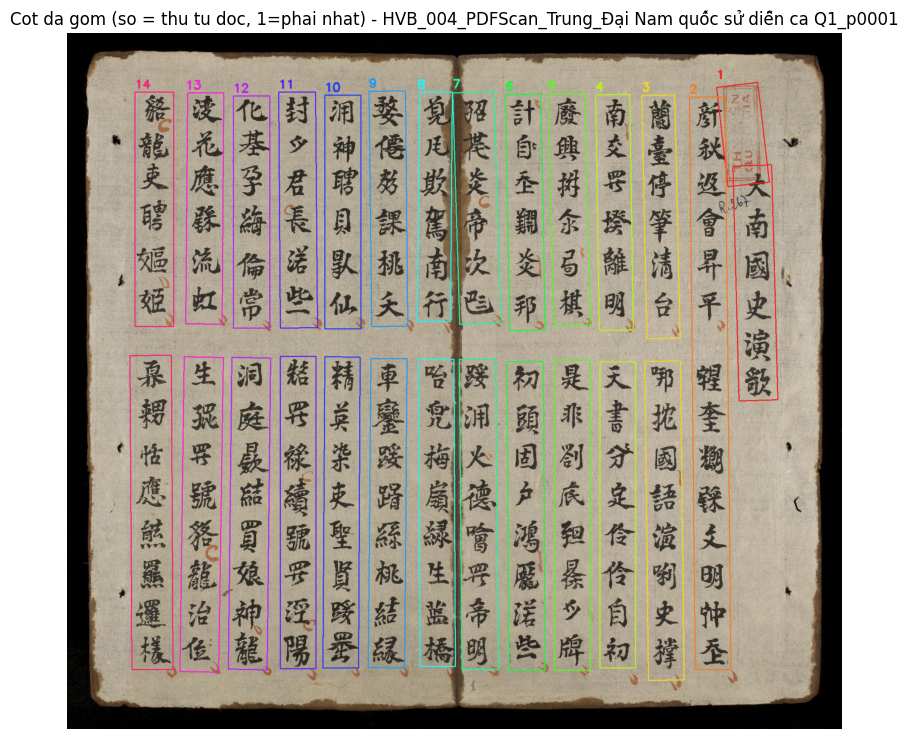

Da luu: /kaggle/working/vis_column/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001_columns.png


In [16]:

import colorsys

def distinct_colors(n):
    colors = []
    for i in range(n):
        h = i / max(n, 1)
        r, g, b = colorsys.hsv_to_rgb(h, 0.85, 0.95)
        colors.append((int(b * 255), int(g * 255), int(r * 255)))  # BGR cho opencv
    return colors

def visualize_columns(image_path, columns, save_path, title=None):
    img = cv2.imread(image_path)
    colors = distinct_colors(len(columns))
    for col_idx, col in enumerate(columns):
        color = colors[col_idx]
        for box in col:
            pts = np.array(box, dtype=np.int32).reshape((-1, 1, 2))
            cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)
        # ghi so thu tu cot (1 = ngoai cung ben phai) canh box dau tien (tren cung) cua cot
        if col:
            top_box = col[0]
            x0, y0 = int(min(p[0] for p in top_box)), int(min(p[1] for p in top_box))
            cv2.putText(img, str(col_idx + 1), (x0, max(y0 - 10, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 3)
    cv2.imwrite(str(save_path), img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 14))
    plt.imshow(img_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

vis_col_path = VIS_COLUMN_DIR / f"{test_page_id}_columns.png"
visualize_columns(test_page_path, test_columns, vis_col_path,
                   title=f"Cot da gom (so = thu tu doc, 1=phai nhat) - {test_page_id}")
print("Da luu:", vis_col_path)


## 6. Cắt ảnh từng cột từ trang gốc (dùng cho bước Recognition)

Da cat 14 anh cot, vi du: [(1, '/kaggle/working/column_crops/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001_col001.png'), (2, '/kaggle/working/column_crops/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001_col002.png'), (3, '/kaggle/working/column_crops/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001/HVB_004_PDFScan_Trung_Đại Nam quốc sử diễn ca Q1_p0001_col003.png')]


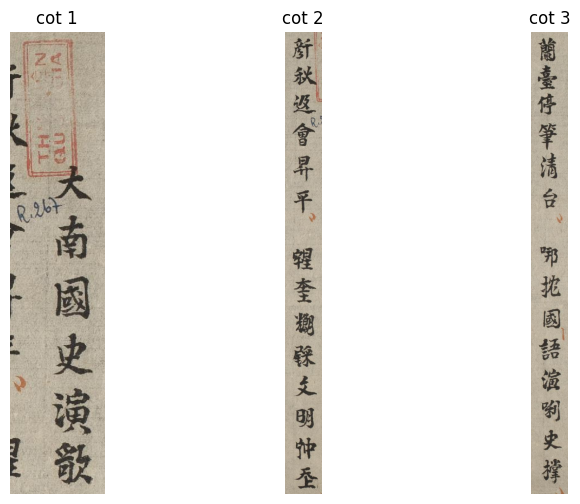

In [17]:
def crop_columns(image_path, columns, save_dir, page_id, pad=6):
    '''
    Cat moi cot thanh 1 anh rieng (bounding box gom tat ca box trong cot + padding).
    Tra ve list tuple (col_idx (1-based, phai->trai), crop_path).
    '''
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    crops = []
    for col_idx, col in enumerate(columns, start=1):
        xs = [p[0] for box in col for p in box]
        ys = [p[1] for box in col for p in box]
        x1 = max(int(min(xs)) - pad, 0)
        y1 = max(int(min(ys)) - pad, 0)
        x2 = min(int(max(xs)) + pad, w)
        y2 = min(int(max(ys)) + pad, h)
        crop = img[y1:y2, x1:x2]
        crop_path = save_dir / f"{page_id}_col{col_idx:03d}.png"
        cv2.imwrite(str(crop_path), crop)
        crops.append((col_idx, str(crop_path)))
    return crops

test_crops = crop_columns(test_page_path, test_columns, COLUMN_CROPS_DIR / test_page_id, test_page_id)
print(f"Da cat {len(test_crops)} anh cot, vi du:", test_crops[:3])

# xem thu 3 anh cot dau tien
fig, axes = plt.subplots(1, min(3, len(test_crops)), figsize=(9, 6))
if len(test_crops) == 1:
    axes = [axes]
for ax, (idx, path) in zip(axes, test_crops[:3]):
    im = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(im)
    ax.set_title(f"cot {idx}")
    ax.axis("off")
plt.show()


## 7. Cài đặt & khởi động Ollama

In [25]:
import subprocess, os

REPO_URL = "https://github.com/tqth/qwen3-vl-4b-hosting.git"
REPO_DIR = "/kaggle/working/qwen3-vl-4b-hosting"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    print("Repo da co san, bo qua clone.")

Cloning into '/kaggle/working/qwen3-vl-4b-hosting'...


In [26]:
import subprocess, time, requests

log_path = "/kaggle/working/start_server.log"
proc = subprocess.Popen(
    ["python", "start_server.py", "--model", "qwen3vl"],
    cwd=REPO_DIR,
    stdout=open(log_path, "w"),
    stderr=subprocess.STDOUT,
)
print(f"Da khoi dong (PID={proc.pid}), doi server load model ...")

for i in range(60):
    try:
        r = requests.get("http://localhost:8000/health", timeout=3)
        if r.status_code == 200:
            print("San sang:", r.json())
            break
    except Exception:
        pass
    time.sleep(15)
    print(f"...{(i+1)*15}s, xem log:", log_path)
else:
    print("Timeout, xem log de debug:")
    print(open(log_path).read()[-3000:])

Da khoi dong (PID=942), doi server load model ...
...15s, xem log: /kaggle/working/start_server.log
...30s, xem log: /kaggle/working/start_server.log
...45s, xem log: /kaggle/working/start_server.log
...60s, xem log: /kaggle/working/start_server.log
San sang: {'model': 'Qwen/Qwen3-VL-4B-Instruct', 'status': 'ok'}


### 8.1 Test nhanh Recognition trên vài cột mẫu — visualize ảnh cột + text nhận được

In [29]:
import subprocess
subprocess.run(["apt-get", "-qq", "update"], check=False)
subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-noto-cjk"], check=False)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 125186 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


CompletedProcess(args=['apt-get', '-qq', 'install', '-y', 'fonts-noto-cjk'], returncode=0)

In [30]:
import matplotlib
import matplotlib.font_manager as fm

cjk_font_paths = [
    p for p in fm.findSystemFonts()
    if "NotoSansCJK" in p or "NotoSerifCJK" in p
]
if cjk_font_paths:
    fm.fontManager.addfont(cjk_font_paths[0])
    cjk_font_name = fm.FontProperties(fname=cjk_font_paths[0]).get_name()
    matplotlib.rcParams["font.family"] = cjk_font_name
    print("Da set font:", cjk_font_name)
else:
    print("Khong tim thay font CJK, kiem tra lai buoc cai fonts-noto-cjk o tren")

Da set font: Noto Sans CJK JP


cot 1: 大南國史演敬
cot 2: 戲秋返會昇平，猩奎觀錄文明仲至
cot 3: 蘭臺停筆清台 呀拖國語演剎史撐


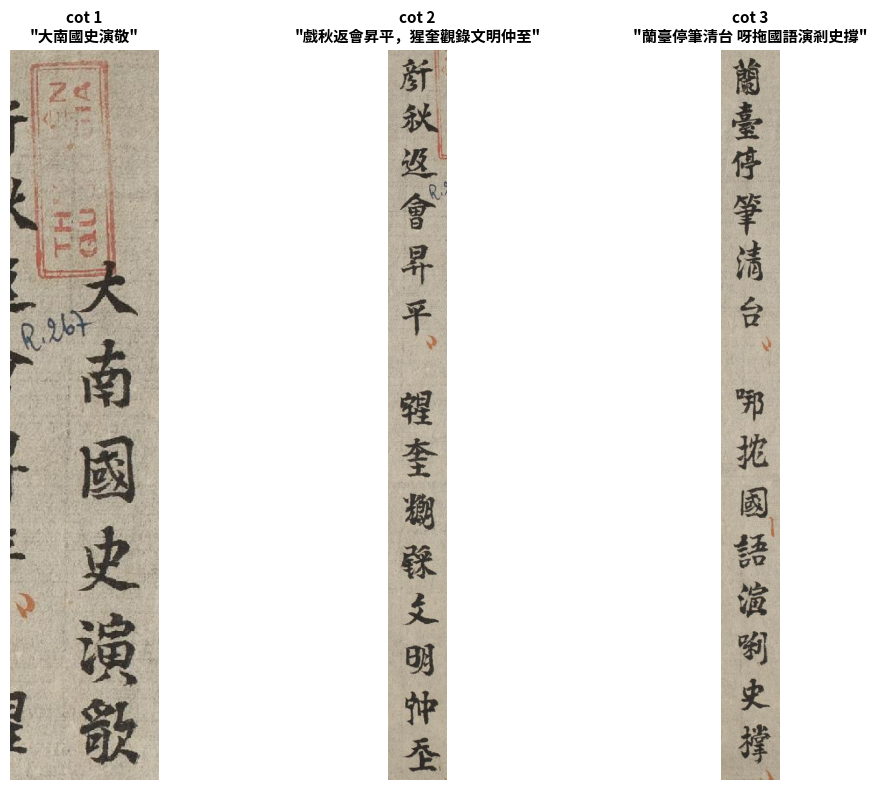

In [31]:
import requests, base64

SERVER_URL = "http://localhost:8000"
RECOGNITION_PROMPT = """
You are an expert OCR engine specialized in Classical Chinese (Hanzi/Hán cổ) documents.

The input image contains EXACTLY ONE isolated vertical column of Chinese characters cropped from an ancient book.

Instructions:
- Read the characters strictly FROM TOP TO BOTTOM.
- Recognize every visible Chinese character as accurately as possible.
- Preserve the original character order exactly.
- Preserve Traditional Chinese characters and historical glyph variants whenever possible.
- Do NOT convert Traditional Chinese characters to Simplified Chinese.
- Do NOT translate, interpret, modernize, normalize, or correct the text.
- Do NOT infer or hallucinate missing characters.
- Do NOT add punctuation, spaces, line breaks, numbering, explanations, or any extra symbols.
- Ignore page borders, decorations, stains, seals, and background noise.
- If a character is unreadable or too ambiguous, output a single '?' in its original position.

Output requirements:
- Return ONLY the recognized Chinese character sequence.
- No markdown.
- No quotation marks.
- No explanations.
- No additional text.
"""

def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def recognize_column(image_path, timeout=60):
    img_b64 = image_to_base64(image_path)
    payload = {
        "messages": [
            {"role": "user", "content": [
                {"type": "text", "text": RECOGNITION_PROMPT},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            ]}
        ],
        "max_tokens": 256,
    }
    r = requests.post(f"{SERVER_URL}/v1/chat/completions", json=payload, timeout=timeout)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"].strip()

# test tren 3 cot dau tien va visualize ket qua canh anh
sample = test_crops[:3]
fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 8))
if len(sample) == 1:
    axes = [axes]

for ax, (col_idx, path) in zip(axes, sample):
    text = recognize_column(path)
    print(f"cot {col_idx}: {text}")
    im = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(im)
    ax.set_title(f"cot {col_idx}\n\"{text}\"", fontsize=11)
    ax.axis("off")
    out_path = VIS_RECOG_DIR / f"{test_page_id}_col{col_idx:03d}_sample.png"
    plt.imsave(out_path, im)

plt.tight_layout()
plt.show()

## 9. Pipeline tổng — chạy toàn bộ trang, ghép text đúng thứ tự, ghi file output

OCR HVB_002:   0%|          | 0/71 [00:00<?, ?it/s]

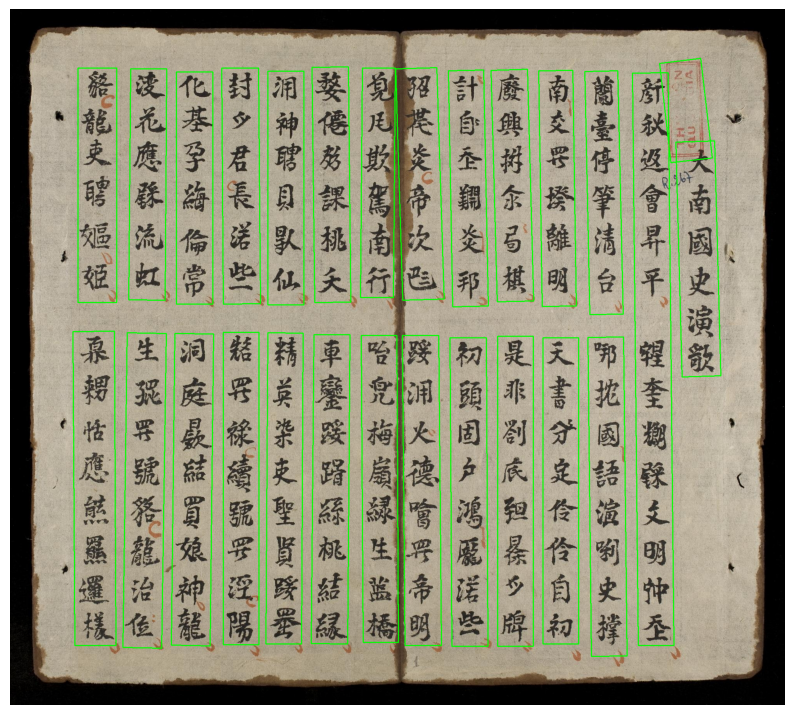

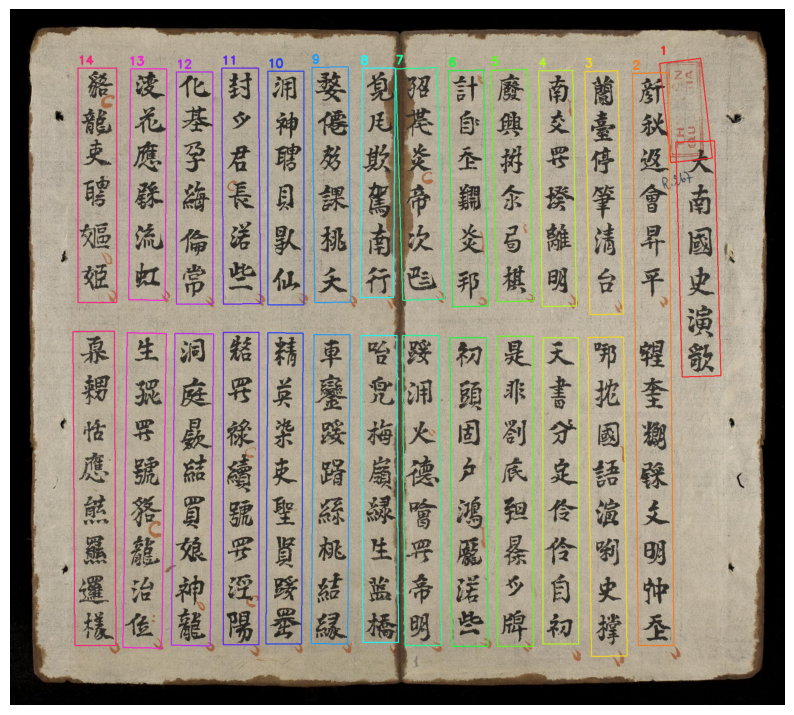

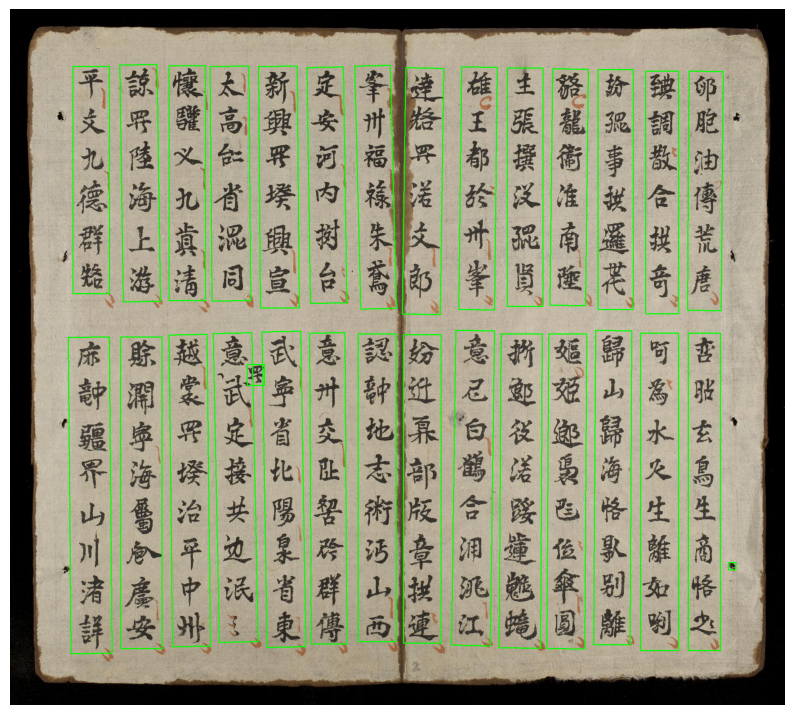

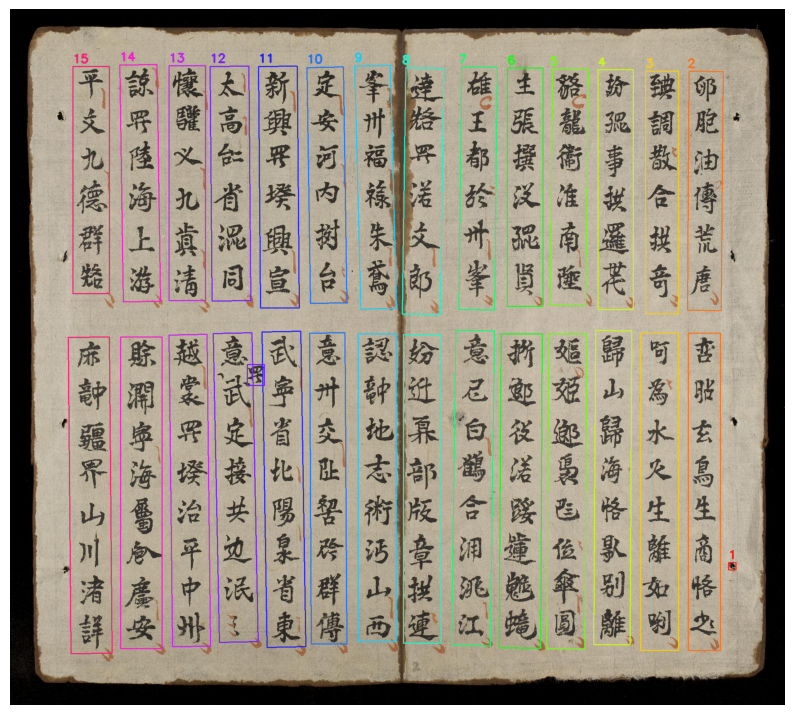

In [ ]:
from tqdm.auto import tqdm

PAGE_BREAK_MARKER = "\n\n===== TRANG MOI =====\n\n"

def process_page(page_id, page_path, save_visuals=True):
    boxes = detect_boxes(page_path)
    columns = group_boxes_into_columns(boxes)
    crops = crop_columns(page_path, columns, COLUMN_CROPS_DIR / page_id, page_id)

    if save_visuals:
        visualize_boxes(page_path, boxes, VIS_DETECT_DIR / f"{page_id}_detect.png", title=None)
        plt.close("all")
        visualize_columns(page_path, columns, VIS_COLUMN_DIR / f"{page_id}_columns.png", title=None)
        plt.close("all")

    column_texts = []
    for col_idx, crop_path in crops:
        text = recognize_column(crop_path)
        column_texts.append(text)

    page_text = "\n".join(column_texts)
    return page_text

all_texts = []
for page_id, page_path in tqdm(page_paths, desc=f"OCR {HVB_ID}"):
    try:
        page_text = process_page(page_id, page_path)
    except Exception as e:
        print(f"[LOI] trang {page_id}: {e}")
        page_text = f"[LOI OCR TRANG {page_id}: {e}]"
    all_texts.append(f"--- {page_id} ---\n{page_text}")

full_text = PAGE_BREAK_MARKER.join(all_texts)

output_path = OUTPUT_DIR / f"raw_text_sino_{HVB_ID}.txt"
output_path.write_text(full_text, encoding="utf-8")
print("Da ghi output:", output_path)
print("Do dai text:", len(full_text), "ky tu")

## 10. Xem nhanh output & đóng gói visualization để tải về kiểm tra

In [ ]:

print(full_text[:2000])
print("...")


In [ ]:

import shutil as _shutil

zip_path = WORK_DIR / f"{HVB_ID}_visualizations"
_shutil.make_archive(str(zip_path), "zip", root_dir=WORK_DIR, base_dir="vis_detect")
# gop them vis_column vao 1 zip khac (hoac gop chung neu muon)
zip_path2 = WORK_DIR / f"{HVB_ID}_vis_columns"
_shutil.make_archive(str(zip_path2), "zip", root_dir=WORK_DIR, base_dir="vis_column")

print("Da dong goi:")
print(" -", str(zip_path) + ".zip")
print(" -", str(zip_path2) + ".zip")
print(" -", output_path)
